# 🥗 FitTrack — Calorie Prediction Model
> **Full ML Pipeline** — Data Loading → Cleaning → Feature Engineering → Training → Evaluation → Export

---

### 📋 What this notebook does
1. Loads USDA FoodData Central (3 CSV files from your Drive)
2. Cleans and merges the data
3. Engineers features from food names + macronutrients
4. Trains and compares multiple ML models
5. Evaluates with detailed metrics and visualizations
6. Exports the best model for AWS Lambda deployment

### 📁 Required files in `My Drive/calories prediction/`
```
food.csv
food_nutrient.csv
nutrient.csv
```
Download from: https://fdc.nal.usda.gov/download-datasets.html


---
## ⚙️ SECTION 1 — Setup & Installations


In [1]:
# Install required packages
!pip install -q scikit-learn pandas numpy matplotlib seaborn joblib xgboost lightgbm shap
print('✅ Packages installed')

✅ Packages installed


In [2]:
# ── Imports ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import re
import os
import json
import joblib
import shap
from pathlib import Path
from scipy.sparse import hstack, csr_matrix

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    r2_score, mean_absolute_percentage_error
)
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    ExtraTreesRegressor, StackingRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Plot style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  'white',
    'text.color':       'white',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'grid.color':       '#2a2a4a',
    'grid.linewidth':   0.5,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
})
PALETTE = ['#00C896', '#FF6B6B', '#4ECDC4', '#FFE66D', '#A8DADC', '#F7AEF8']
PRIMARY  = '#00C896'

print('✅ Imports done')

✅ Imports done


In [3]:
# ── Mount Google Drive ──────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR   = Path('/content/drive/MyDrive/calories prediction')
OUTPUT_DIR = Path('/content/drive/MyDrive/calories prediction/output')
OUTPUT_DIR.mkdir(exist_ok=True)

# Verify files exist
required = ['food.csv', 'food_nutrient.csv', 'nutrient.csv']
for f in required:
    path = DATA_DIR / f
    status = '✅' if path.exists() else '❌ MISSING'
    size   = f'{path.stat().st_size / 1e6:.1f} MB' if path.exists() else ''
    print(f'  {status}  {f}  {size}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  ✅  food.csv  218.0 MB
  ✅  food_nutrient.csv  1785.5 MB
  ✅  nutrient.csv  0.0 MB


---
## 📦 SECTION 2 — Data Loading & Merging


In [4]:
print('Loading CSVs...')

foods    = pd.read_csv(DATA_DIR / 'food.csv',          low_memory=False)[:10**6]
fnuts    = pd.read_csv(DATA_DIR / 'food_nutrient.csv', low_memory=False)[:10**6]
nut_defs = pd.read_csv(DATA_DIR / 'nutrient.csv',      low_memory=False)[:10**6]

print(f'  food.csv          → {len(foods):>8,} rows  |  cols: {list(foods.columns)}')
print(f'  food_nutrient.csv → {len(fnuts):>8,} rows  |  cols: {list(fnuts.columns)}')
print(f'  nutrient.csv      → {len(nut_defs):>8,} rows  |  cols: {list(nut_defs.columns)}')

Loading CSVs...
  food.csv          → 1,000,000 rows  |  cols: ['fdc_id', 'data_type', 'description', 'food_category_id', 'publication_date']
  food_nutrient.csv → 1,000,000 rows  |  cols: ['id', 'fdc_id', 'nutrient_id', 'amount', 'data_points', 'derivation_id', 'min', 'max', 'median', 'loq', 'footnote', 'min_year_acquired', 'percent_daily_value']
  nutrient.csv      →      477 rows  |  cols: ['id', 'name', 'unit_name', 'nutrient_nbr', 'rank']


In [5]:
# ── Identify nutrient IDs ───────────────────────────────────────────────────
# Show available energy/calorie nutrients so we can pick the right ID
energy_rows = nut_defs[
    nut_defs['name'].str.contains('Energy|Calorie|energy|calorie', na=False)
][['id','name','unit_name']]
print('Energy nutrients found:')
print(energy_rows.to_string(index=False))

Energy nutrients found:
  id                              name unit_name
2047  Energy (Atwater General Factors)      KCAL
2048 Energy (Atwater Specific Factors)      KCAL
1008                            Energy      KCAL
1062                            Energy        kJ


In [6]:
# ── Nutrient ID map (USDA standard) ─────────────────────────────────────────
NUTRIENT_IDS = {
    'calories':   1008,   # Energy (kcal)
    'protein_g':  1003,   # Protein
    'fat_g':      1004,   # Total lipid (fat)
    'carbs_g':    1005,   # Carbohydrate, by difference
    'fiber_g':    1079,   # Fiber, total dietary
    'sugar_g':    2000,   # Sugars, total
    'sodium_mg':  1093,   # Sodium
    'saturated_fat_g': 1258,  # Fatty acids, total saturated
}

def extract_nutrient(nutrient_id, col_name):
    """Pull one nutrient column from food_nutrient.csv."""
    return (
        fnuts[fnuts['nutrient_id'] == nutrient_id]
        [['fdc_id', 'amount']]
        .rename(columns={'amount': col_name})
        .drop_duplicates('fdc_id')
    )

# Build base df from foods
df = foods[['fdc_id', 'description', 'data_type']].copy()
df = df.rename(columns={'description': 'food_name'})

# Merge all nutrients
for col, nid in NUTRIENT_IDS.items():
    nutrient_df = extract_nutrient(nid, col)
    df = df.merge(nutrient_df, on='fdc_id', how='left')
    print(f'  Merged {col:<20} → {nutrient_df[col].notna().sum():>7,} values')

print(f'\nMerged dataset: {df.shape}')
df.head(3)

  Merged calories             →  39,448 values
  Merged protein_g            →  39,463 values
  Merged fat_g                →  39,509 values
  Merged carbs_g              →  39,500 values
  Merged fiber_g              →  33,919 values
  Merged sugar_g              →  36,049 values
  Merged sodium_mg            →  39,384 values
  Merged saturated_fat_g      →  34,736 values

Merged dataset: (1000000, 11)


,fdc_id,food_name,data_type,calories,protein_g,fat_g,carbs_g,fiber_g,sugar_g,sodium_mg,saturated_fat_g
0,1105904,WESSON Vegetable Oil 1 GAL,branded_food,867.00,0.00,93.33,0.00,0.00,0.00,0.00,13.33
1,1105905,SWANSON BROTH BEEF,branded_food,4.00,0.83,0.00,0.42,0.00,0.42,346.00,0.00
2,1105906,CAMPBELL'S SLOW KETTLE SOUP CLAM CHOWDER,branded_food,82.00,2.45,5.31,6.12,0.40,0.41,363.00,1.02


---
## 🧹 SECTION 3 — Data Cleaning


In [7]:
print(f'Before cleaning: {len(df):,} rows')
report = {}

# 1 — Drop rows with no food name or no calories
before = len(df)
df = df.dropna(subset=['food_name', 'calories'])
report['no name/calories'] = before - len(df)

# 2 — Remove impossible calorie values
before = len(df)
df = df[(df['calories'] >= 1) & (df['calories'] <= 902)]
report['impossible calories'] = before - len(df)

# 3 — Remove impossible macros
before = len(df)
for col in ['protein_g','fat_g','carbs_g']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    df[col] = df[col].clip(0, 200)
df = df[df['protein_g'] + df['fat_g'] + df['carbs_g'] <= 150]
report['impossible macros'] = before - len(df)

# 4 — Clean food names
df['food_name'] = (
    df['food_name']
    .str.lower()
    .str.strip()
    .apply(lambda x: re.sub(r'[^a-z0-9\s,()%/-]', ' ', str(x)))
    .apply(lambda x: re.sub(r'\s+', ' ', x).strip())
)

# 5 — Remove very short food names
before = len(df)
df = df[df['food_name'].str.len() >= 3]
report['short names'] = before - len(df)

# 6 — Fill missing micronutrients with 0
for col in ['fiber_g','sugar_g','sodium_mg','saturated_fat_g']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# 7 — Remove duplicates (keep first)
before = len(df)
df = df.drop_duplicates(subset='food_name', keep='first')
report['duplicates'] = before - len(df)

df = df.reset_index(drop=True)

print(f'After cleaning:  {len(df):,} rows\n')
print('Rows removed by reason:')
for reason, count in report.items():
    print(f'  {reason:<25} {count:>6,}')

Before cleaning: 1,000,000 rows
After cleaning:  31,779 rows

Rows removed by reason:
  no name/calories          960,552
  impossible calories        2,008
  impossible macros             12
  short names                    0
  duplicates                 5,649


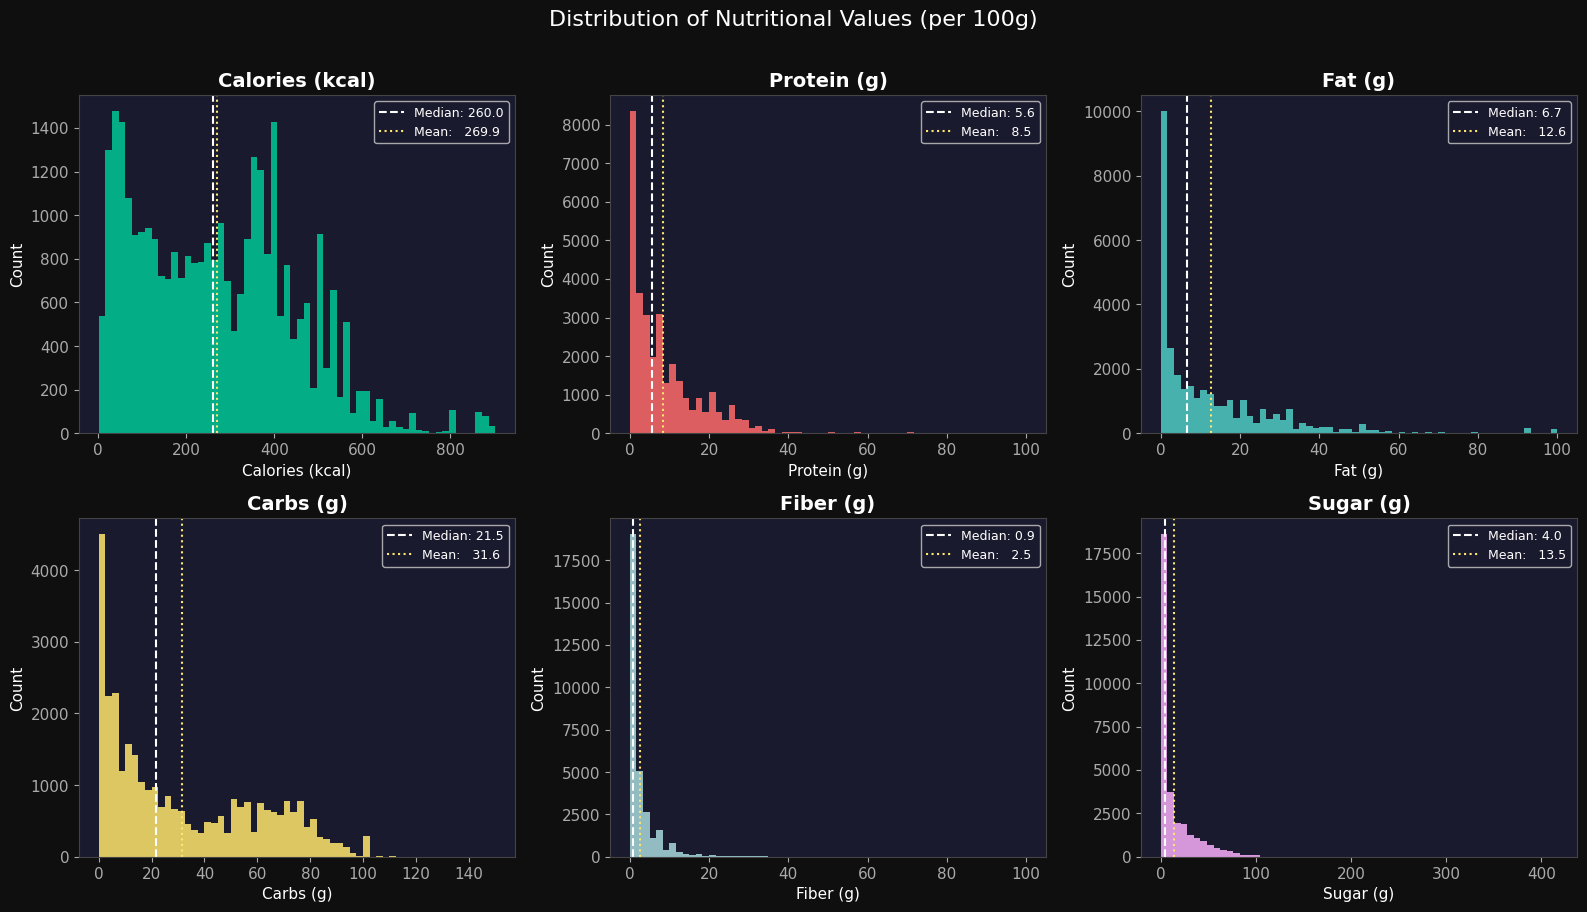

Saved: distributions.png


In [8]:
# ── Visualize cleaned data distribution ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribution of Nutritional Values (per 100g)', fontsize=16, y=1.01)

cols   = ['calories','protein_g','fat_g','carbs_g','fiber_g','sugar_g']
labels = ['Calories (kcal)','Protein (g)','Fat (g)','Carbs (g)','Fiber (g)','Sugar (g)']
colors = PALETTE

for ax, col, label, color in zip(axes.flat, cols, labels, colors):
    data = df[col].dropna()
    ax.hist(data, bins=60, color=color, alpha=0.85, edgecolor='none')
    ax.axvline(data.median(), color='white', linestyle='--', linewidth=1.5,
               label=f'Median: {data.median():.1f}')
    ax.axvline(data.mean(),   color='#FFE66D', linestyle=':',  linewidth=1.5,
               label=f'Mean:   {data.mean():.1f}')
    ax.set_title(label)
    ax.legend(fontsize=9)
    ax.set_xlabel(label)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: distributions.png')

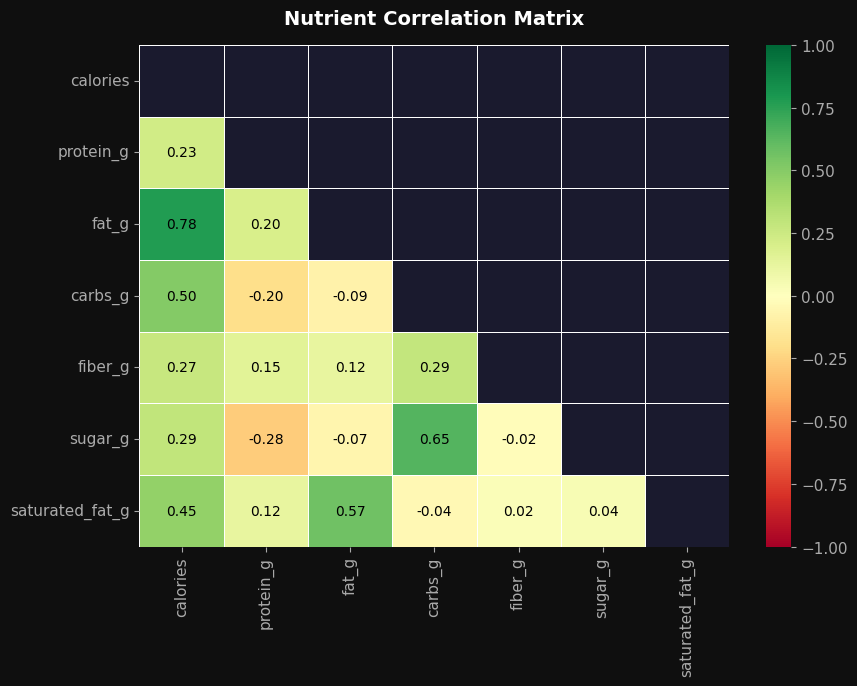


Top correlations with calories:
calories          1.00
fat_g             0.78
carbs_g           0.50
saturated_fat_g   0.45
sugar_g           0.29
fiber_g           0.27
protein_g         0.23


In [9]:
# ── Correlation heatmap ─────────────────────────────────────────────────────
num_cols = ['calories','protein_g','fat_g','carbs_g','fiber_g','sugar_g','saturated_fat_g']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    annot_kws={'size': 10, 'color': 'black'}
)
ax.set_title('Nutrient Correlation Matrix', pad=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop correlations with calories:')
print(corr['calories'].sort_values(ascending=False).to_string())

---
## 🔧 SECTION 4 — Feature Engineering


In [10]:
# ── Caloric density from macros (Atwater factors) ───────────────────────────
# Protein = 4 kcal/g  |  Carbs = 4 kcal/g  |  Fat = 9 kcal/g
df['calculated_calories'] = (
    df['protein_g'] * 4 +
    df['fat_g']     * 9 +
    df['carbs_g']   * 4
)
df['calorie_residual'] = df['calories'] - df['calculated_calories']

# ── Macro ratios ─────────────────────────────────────────────────────────────
total_macros = df['protein_g'] + df['fat_g'] + df['carbs_g']
total_macros = total_macros.replace(0, 1)   # avoid division by zero

df['protein_ratio']  = df['protein_g'] / total_macros
df['fat_ratio']      = df['fat_g']     / total_macros
df['carb_ratio']     = df['carbs_g']   / total_macros
df['fat_per_protein']= df['fat_g']     / (df['protein_g'] + 0.001)
df['sugar_per_carb'] = df['sugar_g']   / (df['carbs_g']   + 0.001)

# ── Calorie category ─────────────────────────────────────────────────────────
bins   = [0, 50, 100, 200, 300, 500, 902]
labels = ['very_low','low','medium','medium_high','high','very_high']
df['calorie_category'] = pd.cut(df['calories'], bins=bins, labels=labels)

# ── Text-based keyword features ──────────────────────────────────────────────
KEYWORD_GROUPS = {
    'is_fried':      ['fried','deep fried','pan fried','crispy'],
    'is_raw':        ['raw','fresh','uncooked','plain'],
    'is_baked':      ['baked','roasted','broiled','grilled'],
    'is_sweet':      ['sugar','sweet','candy','cake','cookie','chocolate','syrup','honey'],
    'is_dairy':      ['milk','cheese','butter','cream','yogurt','ice cream'],
    'is_meat':       ['beef','chicken','pork','turkey','lamb','fish','salmon','tuna','shrimp','bacon'],
    'is_vegetable':  ['broccoli','spinach','lettuce','carrot','celery','cucumber','tomato','pepper'],
    'is_grain':      ['bread','rice','pasta','wheat','oat','flour','cereal','quinoa'],
    'is_nut':        ['almond','peanut','walnut','cashew','pistachio','pecan','nut'],
    'is_oil':        ['oil','lard','shortening','margarine'],
    'is_beverage':   ['juice','soda','drink','water','tea','coffee','beer','wine'],
    'is_sauce':      ['sauce','gravy','dressing','mayo','ketchup','mustard'],
    'is_fast_food':  ['burger','pizza','fries','hotdog','taco','burrito','sandwich'],
    'is_diet':       ['diet','light','low fat','low calorie','reduced','fat free','zero'],
    'is_processed':  ['processed','canned','frozen','instant','packaged'],
    'is_whole':      ['whole','organic','natural','homemade'],
}

for feature, keywords in KEYWORD_GROUPS.items():
    pattern = '|'.join(re.escape(k) for k in keywords)
    df[feature] = df['food_name'].str.contains(pattern, na=False).astype(int)

# ── Name length features ─────────────────────────────────────────────────────
df['name_char_len'] = df['food_name'].str.len()
df['name_word_count']= df['food_name'].str.split().str.len()
df['has_percentage'] = df['food_name'].str.contains('%', na=False).astype(int)
df['has_number']     = df['food_name'].str.contains(r'\d', na=False).astype(int)

print(f'Features created: {df.shape[1]} total columns')
print('\nNew keyword feature counts (positive samples):')
for f in KEYWORD_GROUPS:
    print(f'  {f:<22} {df[f].sum():>5,}')

Features created: 39 total columns

New keyword feature counts (positive samples):
  is_fried                 526
  is_raw                 2,749
  is_baked               1,752
  is_sweet               6,683
  is_dairy               6,478
  is_meat                4,792
  is_vegetable           2,235
  is_grain               3,691
  is_nut                 3,244
  is_oil                 1,280
  is_beverage            3,219
  is_sauce               2,133
  is_fast_food           1,161
  is_diet                1,252
  is_processed           1,391
  is_whole               2,601


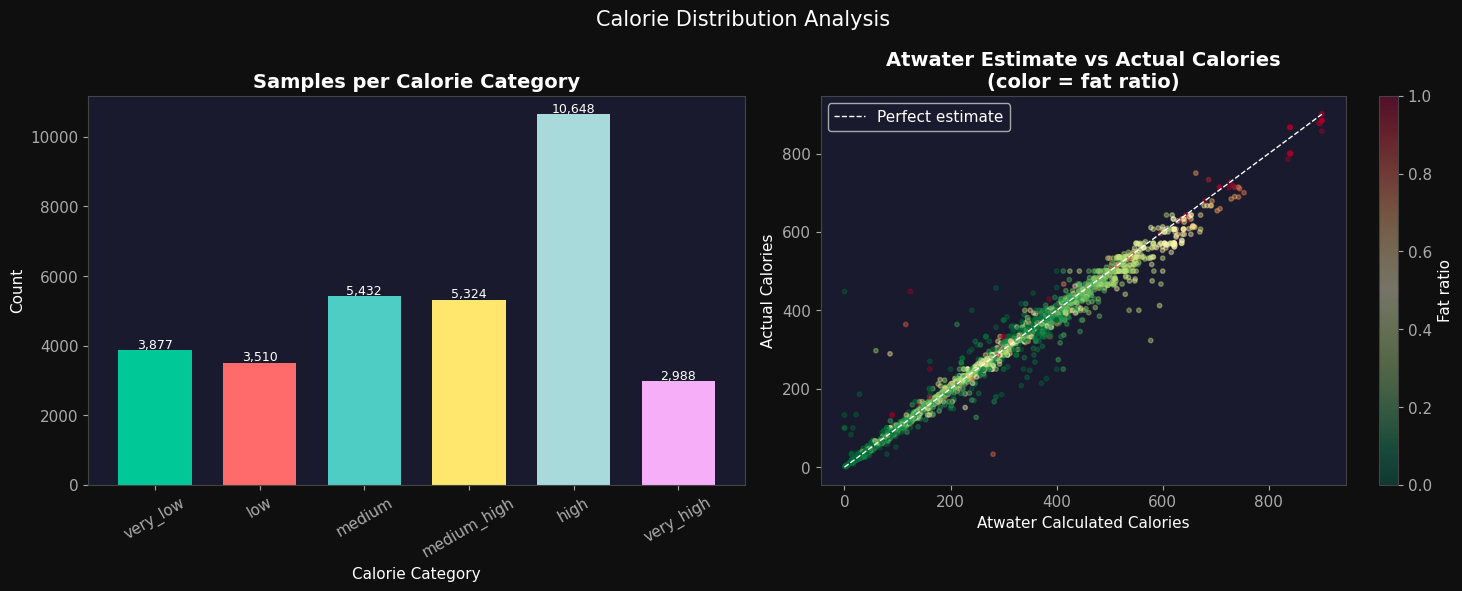

In [11]:
# ── Visualize calorie categories ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Calorie Distribution Analysis', fontsize=15)

# Category distribution
cat_counts = df['calorie_category'].value_counts().sort_index()
axes[0].bar(cat_counts.index, cat_counts.values,
            color=PALETTE[:len(cat_counts)], edgecolor='none', width=0.7)
axes[0].set_title('Samples per Calorie Category')
axes[0].set_xlabel('Calorie Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(cat_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

# Macros vs calories scatter
sample = df.sample(min(3000, len(df)), random_state=42)
sc = axes[1].scatter(
    sample['calculated_calories'], sample['calories'],
    c=sample['fat_ratio'], cmap='RdYlGn_r',
    alpha=0.4, s=10
)
axes[1].plot([0,900],[0,900], color='white', linestyle='--', linewidth=1, label='Perfect estimate')
axes[1].set_title('Atwater Estimate vs Actual Calories\n(color = fat ratio)')
axes[1].set_xlabel('Atwater Calculated Calories')
axes[1].set_ylabel('Actual Calories')
axes[1].legend()
plt.colorbar(sc, ax=axes[1], label='Fat ratio')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'calorie_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

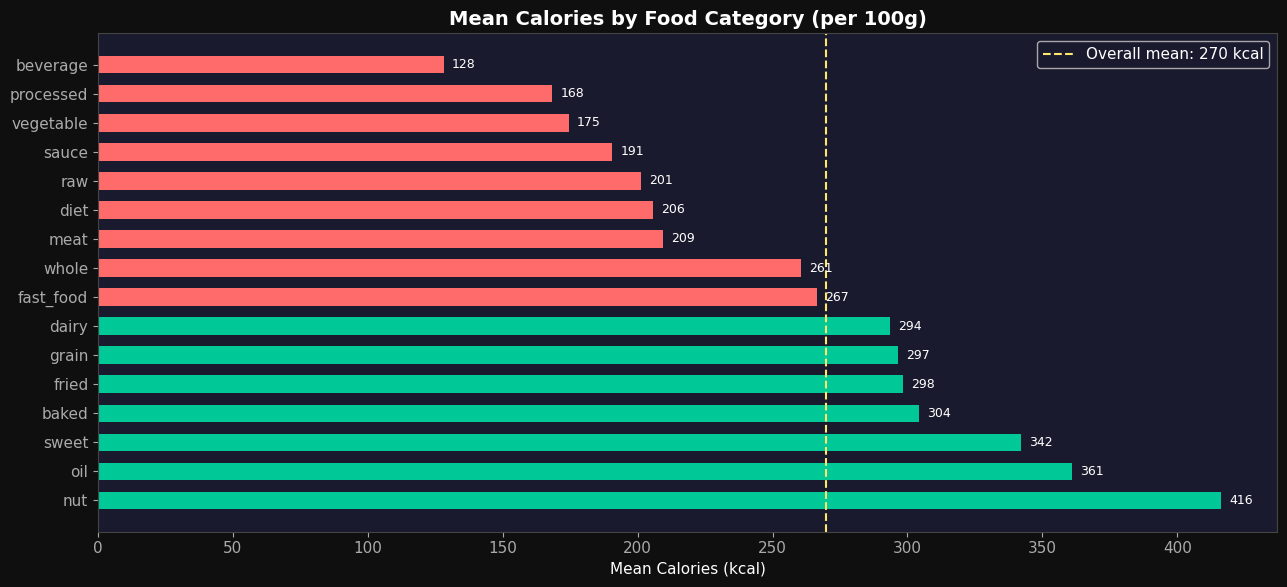

In [12]:
# ── Mean calories per food group ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

groups = [k for k in KEYWORD_GROUPS if k.startswith('is_')]
means  = [(g, df[df[g]==1]['calories'].mean()) for g in groups]
means  = sorted(means, key=lambda x: x[1], reverse=True)

names_  = [m[0].replace('is_','') for m in means]
values_ = [m[1] for m in means]
colors_ = [PRIMARY if v > df['calories'].mean() else '#FF6B6B' for v in values_]

bars = ax.barh(names_, values_, color=colors_, edgecolor='none', height=0.6)
ax.axvline(df['calories'].mean(), color='#FFE66D', linestyle='--',
           linewidth=1.5, label=f'Overall mean: {df["calories"].mean():.0f} kcal')
for bar, val in zip(bars, values_):
    ax.text(val + 3, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=9)
ax.set_title('Mean Calories by Food Category (per 100g)')
ax.set_xlabel('Mean Calories (kcal)')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'calories_by_group.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🤖 SECTION 5 — Model Training


In [13]:
# ── Define feature sets ────────────────────────────────────────────────────
NUMERIC_FEATURES = [
    'protein_g','fat_g','carbs_g','fiber_g','sugar_g',
    'sodium_mg','saturated_fat_g','calculated_calories',
    'protein_ratio','fat_ratio','carb_ratio',
    'fat_per_protein','sugar_per_carb',
    'name_char_len','name_word_count','has_percentage','has_number',
] + list(KEYWORD_GROUPS.keys())

TARGET = 'calories'

# ── Build combined feature matrix ─────────────────────────────────────────
# A) TF-IDF on food names (captures word patterns)
tfidf = TfidfVectorizer(
    ngram_range=(1, 3),
    max_features=5000,
    min_df=2,
    sublinear_tf=True
)

# B) Numeric features
X_num = df[NUMERIC_FEATURES].values.astype(np.float32)
y     = df[TARGET].values.astype(np.float32)

# For tree models: use numeric only (trees handle this better)
# For linear models: use TF-IDF + numeric
X_text_sparse = tfidf.fit_transform(df['food_name'])
X_combined    = hstack([X_text_sparse, csr_matrix(X_num)]).toarray()

print(f'Numeric features:  {X_num.shape}')
print(f'TF-IDF vocabulary: {len(tfidf.vocabulary_):,} terms')
print(f'Combined matrix:   {X_combined.shape}')

# ── Train/val/test split (70/15/15) ───────────────────────────────────────
X_temp, X_test, y_temp, y_test = train_test_split(
    X_combined, y, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42  # 0.176 * 0.85 ≈ 0.15
)

# Also split numeric-only for tree models
X_num_temp, X_num_test, _, _ = train_test_split(
    X_num, y, test_size=0.15, random_state=42
)
X_num_train, X_num_val, _, _ = train_test_split(
    X_num_temp, y_temp, test_size=0.176, random_state=42
)

print(f'\nTrain: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}')

Numeric features:  (31779, 33)
TF-IDF vocabulary: 5,000 terms
Combined matrix:   (31779, 5033)

Train: 22,257  |  Val: 4,755  |  Test: 4,767


In [14]:
# ── Train all models ──────────────────────────────────────────────────────
def evaluate(model, X_tr, y_tr, X_va, y_va, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds_val  = np.clip(model.predict(X_va), 0, 902)
    preds_test = np.clip(model.predict(X_te), 0, 902)
    return {
        'val_mae':   mean_absolute_error(y_va, preds_val),
        'val_rmse':  np.sqrt(mean_squared_error(y_va, preds_val)),
        'val_r2':    r2_score(y_va, preds_val),
        'test_mae':  mean_absolute_error(y_te, preds_test),
        'test_rmse': np.sqrt(mean_squared_error(y_te, preds_test)),
        'test_r2':   r2_score(y_te, preds_test),
        'test_preds': preds_test,
    }

MODELS = {
    # Tree models (numeric features only — they don't benefit from TF-IDF scaling)
    'XGBoost': (
        XGBRegressor(
            n_estimators=500, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0,
            random_state=42, verbosity=0, n_jobs=-1
        ),
        X_num_train, y_train, X_num_val, y_val, X_num_test, y_test
    ),
    'LightGBM': (
        LGBMRegressor(
            n_estimators=500, max_depth=6, learning_rate=0.05,
            num_leaves=63, subsample=0.8, colsample_bytree=0.8,
            random_state=42, verbose=-1, n_jobs=-1
        ),
        X_num_train, y_train, X_num_val, y_val, X_num_test, y_test
    ),
    'RandomForest': (
        RandomForestRegressor(
            n_estimators=300, max_depth=12, min_samples_leaf=2,
            random_state=42, n_jobs=-1
        ),
        X_num_train, y_train, X_num_val, y_val, X_num_test, y_test
    ),
    'GradientBoosting': (
        GradientBoostingRegressor(
            n_estimators=300, max_depth=5, learning_rate=0.08,
            subsample=0.8, random_state=42
        ),
        X_num_train, y_train, X_num_val, y_val, X_num_test, y_test
    ),
    'ExtraTrees': (
        ExtraTreesRegressor(
            n_estimators=300, max_depth=12, random_state=42, n_jobs=-1
        ),
        X_num_train, y_train, X_num_val, y_val, X_num_test, y_test
    ),
    # Linear models (combined TF-IDF + numeric)
    'Ridge': (
        Ridge(alpha=10.0),
        X_train, y_train, X_val, y_val, X_test, y_test
    ),
    'ElasticNet': (
        ElasticNet(alpha=0.5, l1_ratio=0.5, max_iter=2000),
        X_train, y_train, X_val, y_val, X_test, y_test
    ),
}

results = {}
for name, args in MODELS.items():
    print(f'Training {name}...', end=' ')
    model_obj = args[0]
    metrics   = evaluate(model_obj, *args[1:])
    results[name] = {'model': model_obj, **metrics}
    print(f'Val MAE: {metrics["val_mae"]:6.2f} kcal  |  Test R²: {metrics["test_r2"]:.4f}')

print('\n✅ All models trained')

Training XGBoost... Val MAE:  11.32 kcal  |  Test R²: 0.9811
Training LightGBM... Val MAE:  11.78 kcal  |  Test R²: 0.9817
Training RandomForest... Val MAE:  11.11 kcal  |  Test R²: 0.9795
Training GradientBoosting... Val MAE:  11.42 kcal  |  Test R²: 0.9807
Training ExtraTrees... Val MAE:  11.20 kcal  |  Test R²: 0.9802
Training Ridge... Val MAE:  12.55 kcal  |  Test R²: 0.9791
Training ElasticNet... Val MAE:  13.50 kcal  |  Test R²: 0.9762

✅ All models trained


---
## 📊 SECTION 6 — Evaluation & Comparison


In [15]:
# ── Summary table ─────────────────────────────────────────────────────────
summary = []
for name, r in results.items():
    summary.append({
        'Model':     name,
        'Val MAE':   round(r['val_mae'],  2),
        'Val RMSE':  round(r['val_rmse'], 2),
        'Val R²':    round(r['val_r2'],   4),
        'Test MAE':  round(r['test_mae'], 2),
        'Test RMSE': round(r['test_rmse'],2),
        'Test R²':   round(r['test_r2'],  4),
    })

summary_df = pd.DataFrame(summary).sort_values('Test MAE')
print('═'*75)
print(summary_df.to_string(index=False))
print('═'*75)

BEST_NAME  = summary_df.iloc[0]['Model']
BEST_MODEL = results[BEST_NAME]['model']
print(f'\n🏆 Best model: {BEST_NAME}')
print(f'   Test MAE:  {results[BEST_NAME]["test_mae"]:.2f} kcal')
print(f'   Test RMSE: {results[BEST_NAME]["test_rmse"]:.2f} kcal')
print(f'   Test R²:   {results[BEST_NAME]["test_r2"]:.4f}')

═══════════════════════════════════════════════════════════════════════════
           Model  Val MAE  Val RMSE  Val R²  Test MAE  Test RMSE  Test R²
      ExtraTrees    11.20     23.21    0.98     10.89      25.11     0.98
    RandomForest    11.11     23.25    0.98     10.93      25.61     0.98
         XGBoost    11.32     23.13    0.98     10.94      24.53     0.98
GradientBoosting    11.42     23.34    0.98     11.02      24.85     0.98
        LightGBM    11.78     23.38    0.98     11.08      24.19     0.98
           Ridge    12.55     25.59    0.98     11.87      25.83     0.98
      ElasticNet    13.50     28.09    0.98     12.59      27.54     0.98
═══════════════════════════════════════════════════════════════════════════

🏆 Best model: ExtraTrees
   Test MAE:  10.89 kcal
   Test RMSE: 25.11 kcal
   Test R²:   0.9802


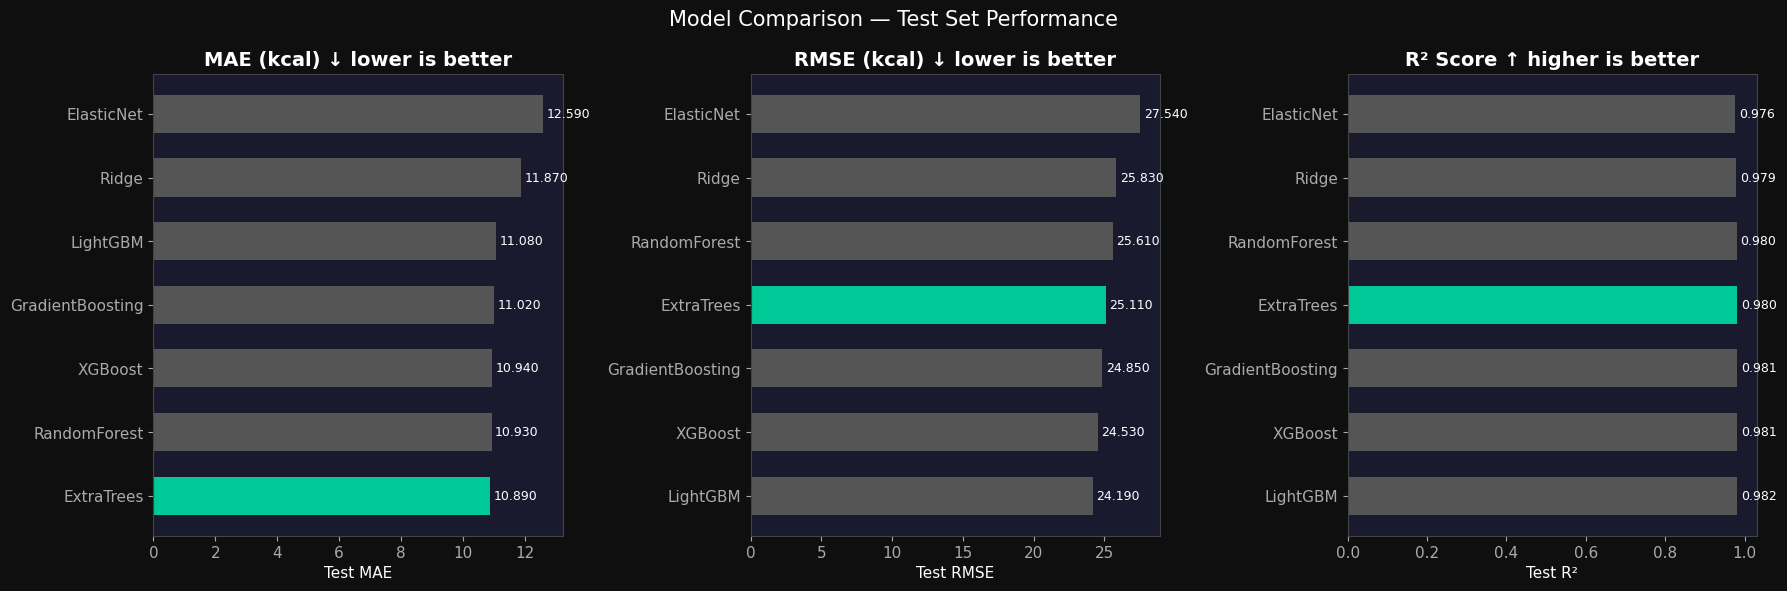

In [16]:
# ── Model comparison chart ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Comparison — Test Set Performance', fontsize=15)

metrics_plot = ['Test MAE','Test RMSE','Test R²']
titles_      = ['MAE (kcal) ↓ lower is better',
                'RMSE (kcal) ↓ lower is better',
                'R² Score ↑ higher is better']
ascending_   = [True, True, False]

for ax, metric, title, asc in zip(axes, metrics_plot, titles_, ascending_):
    data_ = summary_df.sort_values(metric, ascending=asc)
    colors_ = [PRIMARY if n == BEST_NAME else '#555' for n in data_['Model']]
    bars = ax.barh(data_['Model'], data_[metric], color=colors_, height=0.6)
    for bar, val in zip(bars, data_[metric]):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    ax.set_title(title)
    ax.set_xlabel(metric)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

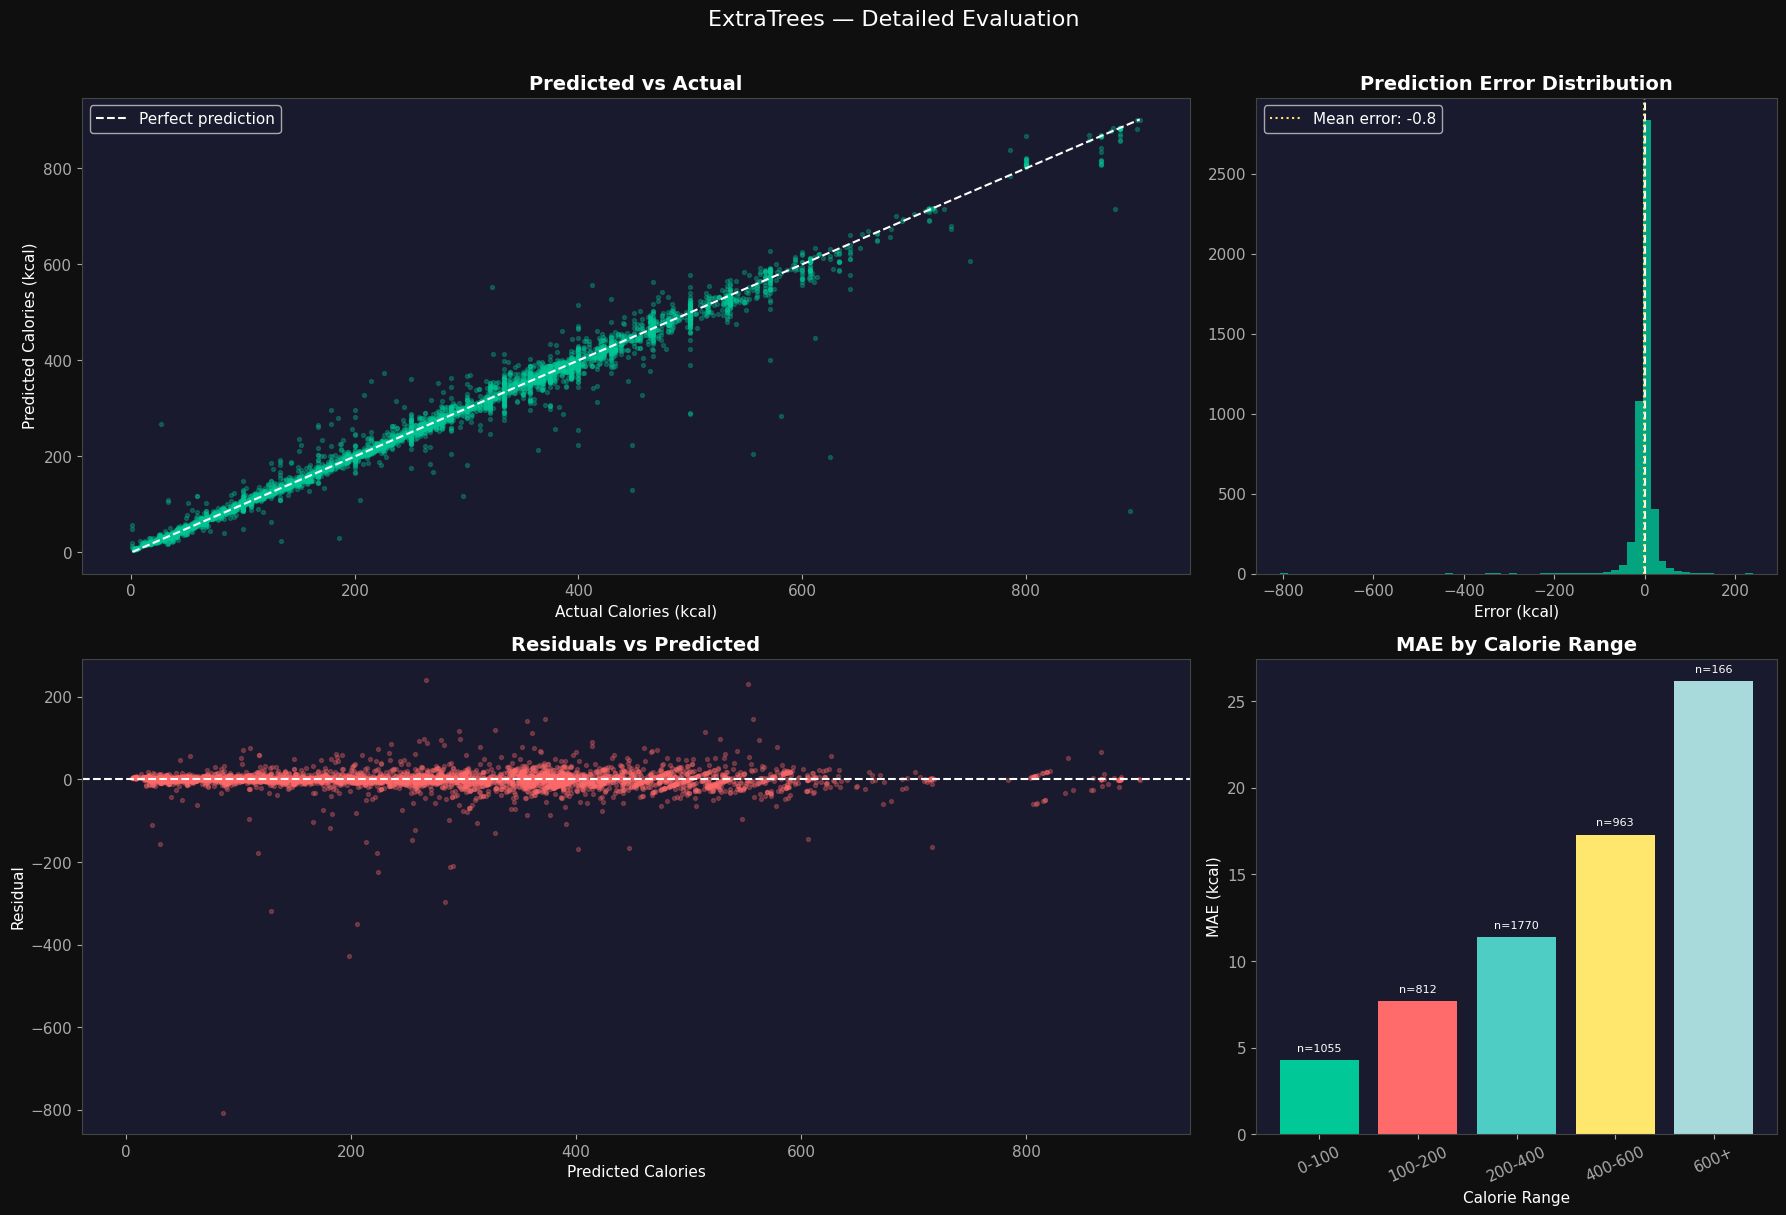


Detailed Error Statistics:
  Mean Error (bias):        -0.84 kcal
  Std of errors:            25.09 kcal
  Within ±10 kcal:          68.9%
  Within ±25 kcal:          90.7%
  Within ±50 kcal:          97.3%
  Within ±100 kcal:         99.3%


In [17]:
# ── Prediction vs Actual — best model ────────────────────────────────────
best_preds = results[BEST_NAME]['test_preds']
errors     = best_preds - y_test

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig)
fig.suptitle(f'{BEST_NAME} — Detailed Evaluation', fontsize=16, y=1.01)

# 1 — Predicted vs Actual
ax1 = fig.add_subplot(gs[0, 0:2])
ax1.scatter(y_test, best_preds, alpha=0.3, s=8, color=PRIMARY)
mn, mx = min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())
ax1.plot([mn,mx],[mn,mx], color='white', linestyle='--', linewidth=1.5, label='Perfect prediction')
ax1.set_xlabel('Actual Calories (kcal)')
ax1.set_ylabel('Predicted Calories (kcal)')
ax1.set_title('Predicted vs Actual')
ax1.legend()

# 2 — Error distribution
ax2 = fig.add_subplot(gs[0, 2])
ax2.hist(errors, bins=60, color=PRIMARY, alpha=0.8, edgecolor='none')
ax2.axvline(0,  color='white', linestyle='--', linewidth=1.5)
ax2.axvline(np.mean(errors),  color='#FFE66D', linestyle=':', linewidth=1.5,
            label=f'Mean error: {np.mean(errors):.1f}')
ax2.set_title('Prediction Error Distribution')
ax2.set_xlabel('Error (kcal)')
ax2.legend()

# 3 — Residuals vs Predicted
ax3 = fig.add_subplot(gs[1, 0:2])
ax3.scatter(best_preds, errors, alpha=0.3, s=8, color='#FF6B6B')
ax3.axhline(0, color='white', linestyle='--', linewidth=1.5)
ax3.set_xlabel('Predicted Calories')
ax3.set_ylabel('Residual')
ax3.set_title('Residuals vs Predicted')

# 4 — Error by calorie range
ax4 = fig.add_subplot(gs[1, 2])
ranges = [(0,100,'0-100'),(100,200,'100-200'),(200,400,'200-400'),(400,600,'400-600'),(600,902,'600+')]
range_maes = []
for lo, hi, label in ranges:
    mask = (y_test >= lo) & (y_test < hi)
    if mask.sum() > 0:
        range_maes.append((label, mean_absolute_error(y_test[mask], best_preds[mask]), mask.sum()))
labels_, maes_, counts_ = zip(*range_maes)
bars = ax4.bar(labels_, maes_, color=PALETTE[:len(labels_)], edgecolor='none')
for bar, count in zip(bars, counts_):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'n={count}', ha='center', fontsize=8)
ax4.set_title('MAE by Calorie Range')
ax4.set_xlabel('Calorie Range')
ax4.set_ylabel('MAE (kcal)')
ax4.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'evaluation_detail.png', dpi=150, bbox_inches='tight')
plt.show()

# Print detailed stats
print(f'\nDetailed Error Statistics:')
print(f'  Mean Error (bias):     {np.mean(errors):>8.2f} kcal')
print(f'  Std of errors:         {np.std(errors):>8.2f} kcal')
print(f'  Within ±10 kcal:       {(np.abs(errors)<=10).mean()*100:>7.1f}%')
print(f'  Within ±25 kcal:       {(np.abs(errors)<=25).mean()*100:>7.1f}%')
print(f'  Within ±50 kcal:       {(np.abs(errors)<=50).mean()*100:>7.1f}%')
print(f'  Within ±100 kcal:      {(np.abs(errors)<=100).mean()*100:>7.1f}%')

In [18]:
# ── Cross-validation on best model ────────────────────────────────────────
print(f'Running 5-fold cross-validation on {BEST_NAME}...')

# Use numeric features for tree models
X_cv = X_num if BEST_NAME not in ['Ridge','ElasticNet'] else X_combined

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_maes = []
cv_r2s  = []

for fold, (tr_idx, va_idx) in enumerate(cv.split(X_cv)):
    X_tr_, X_va_ = X_cv[tr_idx], X_cv[va_idx]
    y_tr_, y_va_ = y[tr_idx],    y[va_idx]
    BEST_MODEL.fit(X_tr_, y_tr_)
    preds_ = np.clip(BEST_MODEL.predict(X_va_), 0, 902)
    mae_   = mean_absolute_error(y_va_, preds_)
    r2_    = r2_score(y_va_, preds_)
    cv_maes.append(mae_)
    cv_r2s.append(r2_)
    print(f'  Fold {fold+1}: MAE = {mae_:.2f}  R² = {r2_:.4f}')

print(f'\nCross-validation summary:')
print(f'  MAE: {np.mean(cv_maes):.2f} ± {np.std(cv_maes):.2f} kcal')
print(f'  R²:  {np.mean(cv_r2s):.4f} ± {np.std(cv_r2s):.4f}')

Running 5-fold cross-validation on ExtraTrees...
  Fold 1: MAE = 10.65  R² = 0.9827
  Fold 2: MAE = 11.01  R² = 0.9788
  Fold 3: MAE = 10.87  R² = 0.9833
  Fold 4: MAE = 11.03  R² = 0.9826
  Fold 5: MAE = 11.00  R² = 0.9829

Cross-validation summary:
  MAE: 10.91 ± 0.14 kcal
  R²:  0.9821 ± 0.0017


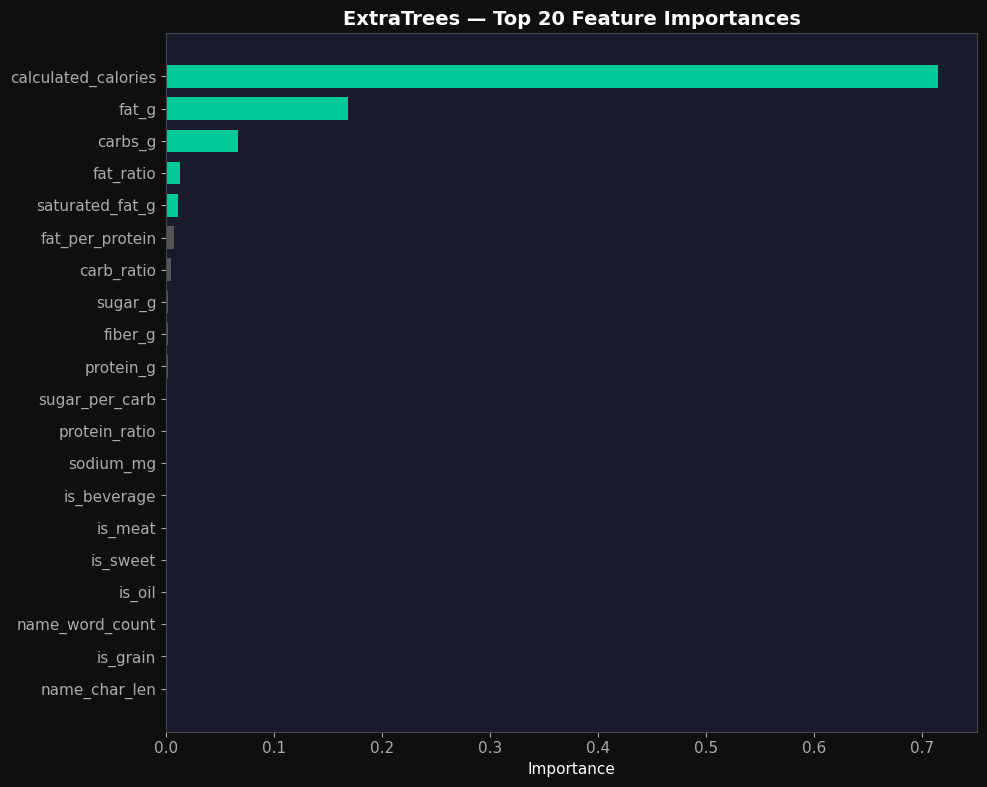


Top 10 features:
            feature  importance
calculated_calories        0.71
              fat_g        0.17
            carbs_g        0.07
          fat_ratio        0.01
    saturated_fat_g        0.01
    fat_per_protein        0.01
         carb_ratio        0.00
            sugar_g        0.00
            fiber_g        0.00
          protein_g        0.00


In [19]:
# ── Feature importance (tree models only) ────────────────────────────────
if hasattr(BEST_MODEL, 'feature_importances_'):
    importances = BEST_MODEL.feature_importances_
    feat_imp_df = pd.DataFrame({
        'feature':    NUMERIC_FEATURES,
        'importance': importances
    }).sort_values('importance', ascending=False)

    fig, ax = plt.subplots(figsize=(10, 8))
    top20 = feat_imp_df.head(20)
    colors_ = [PRIMARY if i < 5 else '#555' for i in range(len(top20))]
    ax.barh(top20['feature'][::-1], top20['importance'][::-1],
            color=colors_[::-1], edgecolor='none', height=0.7)
    ax.set_title(f'{BEST_NAME} — Top 20 Feature Importances')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nTop 10 features:')
    print(feat_imp_df.head(10).to_string(index=False))
else:
    print('Feature importance not available for this model type.')

Computing SHAP values (sample of 500)...


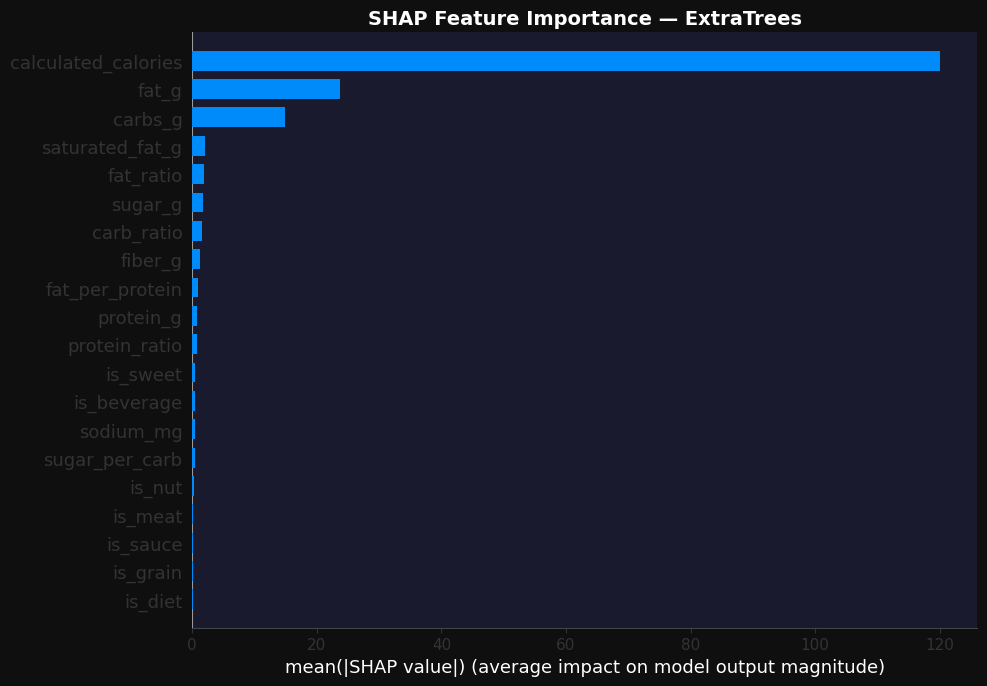

✅ SHAP done


In [20]:
# ── SHAP values (explainability) ──────────────────────────────────────────
print('Computing SHAP values (sample of 500)...')

X_cv = X_num if BEST_NAME not in ['Ridge','ElasticNet'] else X_combined
sample_idx = np.random.choice(len(X_cv), 500, replace=False)
X_shap     = X_cv[sample_idx]

if BEST_NAME in ['XGBoost','LightGBM','RandomForest','GradientBoosting','ExtraTrees']:
    explainer   = shap.TreeExplainer(BEST_MODEL)
    shap_values = explainer.shap_values(X_shap)

    fig, ax = plt.subplots(figsize=(10, 7))
    shap.summary_plot(
        shap_values, X_shap,
        feature_names=NUMERIC_FEATURES,
        plot_type='bar',
        show=False,
        plot_size=None
    )
    plt.title(f'SHAP Feature Importance — {BEST_NAME}')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'shap_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
print('✅ SHAP done')

---
## 🧪 SECTION 7 — Live Prediction Test


In [21]:
# ── Retrain best model on full dataset before saving ──────────────────────
print(f'Retraining {BEST_NAME} on full dataset...')
X_full = X_num if BEST_NAME not in ['Ridge','ElasticNet'] else X_combined
BEST_MODEL.fit(X_full, y)
print('✅ Done')

Retraining ExtraTrees on full dataset...
✅ Done


In [22]:
# ── Prediction function ───────────────────────────────────────────────────
def predict_calories(food_name, protein_g=0, fat_g=0, carbs_g=0,
                     fiber_g=0, sugar_g=0, sodium_mg=0, saturated_fat_g=0):
    """
    Predict calories for a food item.
    If macros are known, pass them in for much better accuracy.
    If only the name is known, keyword features will be used.
    """
    name  = food_name.lower().strip()
    total = protein_g + fat_g + carbs_g
    total = total if total > 0 else 1

    calc_cal = protein_g*4 + fat_g*9 + carbs_g*4

    features = [
        protein_g, fat_g, carbs_g, fiber_g, sugar_g,
        sodium_mg, saturated_fat_g, calc_cal,
        protein_g/total, fat_g/total, carbs_g/total,
        fat_g/(protein_g+0.001), sugar_g/(carbs_g+0.001),
        len(name), len(name.split()),
        int('%' in name), int(bool(re.search(r'\d', name))),
    ]

    for kw_name, keywords in KEYWORD_GROUPS.items():
        pattern = '|'.join(re.escape(k) for k in keywords)
        features.append(int(bool(re.search(pattern, name))))

    X_input = np.array(features, dtype=np.float32).reshape(1, -1)

    if BEST_NAME not in ['Ridge','ElasticNet']:
        prediction = BEST_MODEL.predict(X_input)[0]
    else:
        text_feat  = tfidf.transform([name])
        combined   = hstack([text_feat, csr_matrix(X_input)]).toarray()
        prediction = BEST_MODEL.predict(combined)[0]

    return round(float(np.clip(prediction, 0, 902)), 1)


# ── Test with common foods ────────────────────────────────────────────────
test_foods = [
    # (name, protein, fat, carbs, actual_calories)
    ('apple raw',              0.3,  0.2, 14.0,  52),
    ('banana raw',             1.1,  0.3, 23.0,  89),
    ('chicken breast cooked', 31.0,  3.6,  0.0, 165),
    ('butter salted',          0.9, 81.0,  0.1, 717),
    ('white rice cooked',      2.7,  0.3, 28.0, 130),
    ('broccoli raw',           2.8,  0.4,  7.0,  34),
    ('cheddar cheese',        25.0, 33.0,  1.3, 403),
    ('coca cola',              0.0,  0.0, 10.6,  42),
    ('olive oil',              0.0,100.0,  0.0, 884),
    ('egg whole cooked',      13.0, 10.0,  1.1, 155),
    ('bacon cooked',          37.0, 42.0,  1.4, 541),
    ('lettuce raw',            1.4,  0.2,  2.9,  15),
    # Name-only predictions (no macros)
    ('fried chicken', 0, 0, 0, 260),
    ('caesar salad',  0, 0, 0, 190),
    ('chocolate cake',0, 0, 0, 371),
]

print(f'{'Food':<30} {'Predicted':>10} {'Actual':>10} {'Error':>10}')
print('─'*65)
errors_test = []
for food, prot, fat, carb, actual in test_foods:
    pred  = predict_calories(food, prot, fat, carb)
    error = pred - actual
    errors_test.append(abs(error))
    flag  = '✅' if abs(error) <= 30 else ('⚠️' if abs(error) <= 60 else '❌')
    print(f'{flag} {food:<28} {pred:>10.1f} {actual:>10}  ({error:+.1f})')

print('─'*65)
print(f'Mean Absolute Error on test foods: {np.mean(errors_test):.1f} kcal')

Food                            Predicted     Actual      Error
─────────────────────────────────────────────────────────────────
✅ apple raw                          58.4         52  (+6.4)
✅ banana raw                         98.8         89  (+9.8)
✅ chicken breast cooked             158.6        165  (-6.4)
✅ butter salted                     727.5        717  (+10.5)
✅ white rice cooked                 125.4        130  (-4.6)
✅ broccoli raw                       39.4         34  (+5.4)
✅ cheddar cheese                    393.5        403  (-9.5)
✅ coca cola                          41.2         42  (-0.8)
✅ olive oil                         876.6        884  (-7.4)
✅ egg whole cooked                  147.1        155  (-7.9)
✅ bacon cooked                      523.2        541  (-17.8)
✅ lettuce raw                        19.0         15  (+4.0)
✅ fried chicken                     259.5        260  (-0.5)
❌ caesar salad                      272.2        190  (+82.2)
⚠️ chocolate 

---
## 💾 SECTION 8 — Save Model & Export for AWS


In [23]:
# ── Save all artifacts to Drive ──────────────────────────────────────────
print('Saving model artifacts...')

# 1 — Model
joblib.dump(BEST_MODEL, OUTPUT_DIR / 'calorie_model.joblib', compress=3)
print(f'  ✅ calorie_model.joblib  ({(OUTPUT_DIR/"calorie_model.joblib").stat().st_size/1e6:.1f} MB)')

# 2 — TF-IDF vectorizer (needed for linear models)
joblib.dump(tfidf, OUTPUT_DIR / 'tfidf_vectorizer.joblib', compress=3)
print(f'  ✅ tfidf_vectorizer.joblib')

# 3 — Feature config (needed for Lambda inference)
config = {
    'model_type':       BEST_NAME,
    'numeric_features': NUMERIC_FEATURES,
    'keyword_groups':   KEYWORD_GROUPS,
    'test_mae':         round(results[BEST_NAME]['test_mae'], 2),
    'test_r2':          round(results[BEST_NAME]['test_r2'],  4),
    'cv_mae_mean':      round(float(np.mean(cv_maes)), 2),
    'cv_mae_std':       round(float(np.std(cv_maes)),  2),
    'training_samples': int(len(y)),
    'uses_tfidf':       BEST_NAME in ['Ridge','ElasticNet'],
}
with open(OUTPUT_DIR / 'model_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print(f'  ✅ model_config.json')

# 4 — Clean dataset CSV
df[['food_name','calories','protein_g','fat_g','carbs_g']].to_csv(
    OUTPUT_DIR / 'clean_food_data.csv', index=False
)
print(f'  ✅ clean_food_data.csv  ({len(df):,} foods)')

print(f'\nAll artifacts saved to: {OUTPUT_DIR}')

Saving model artifacts...
  ✅ calorie_model.joblib  (16.5 MB)
  ✅ tfidf_vectorizer.joblib
  ✅ model_config.json
  ✅ clean_food_data.csv  (31,779 foods)

All artifacts saved to: /content/drive/MyDrive/calories prediction/output


In [24]:
# ── Generate Lambda inference code ────────────────────────────────────────
lambda_code = '''
import json, os, re, boto3, joblib, numpy as np
from scipy.sparse import hstack, csr_matrix

S3_BUCKET  = os.environ.get('MODEL_BUCKET', 'fitness-tracker-mvp-models')
_model     = None
_tfidf     = None
_config    = None

KEYWORD_GROUPS = ''' + json.dumps(KEYWORD_GROUPS) + '''

NUMERIC_FEATURES = ''' + json.dumps(NUMERIC_FEATURES) + '''

def _load():
    global _model, _tfidf, _config
    if _model: return
    s3 = boto3.client("s3")
    s3.download_file(S3_BUCKET, "calorie_model.joblib",   "/tmp/model.joblib")
    s3.download_file(S3_BUCKET, "model_config.json",      "/tmp/config.json")
    _model  = joblib.load("/tmp/model.joblib")
    with open("/tmp/config.json") as f:
        _config = json.load(f)
    if _config.get("uses_tfidf"):
        s3.download_file(S3_BUCKET, "tfidf_vectorizer.joblib", "/tmp/tfidf.joblib")
        _tfidf = joblib.load("/tmp/tfidf.joblib")

def _build_features(name, p=0, f=0, c=0, fi=0, s=0, na=0, sf=0):
    total = (p+f+c) or 1
    calc  = p*4 + f*9 + c*4
    feats = [p,f,c,fi,s,na,sf,calc, p/total,f/total,c/total,
             f/(p+0.001), s/(c+0.001), len(name), len(name.split()),
             int("%" in name), int(bool(re.search(r"\\d", name)))]
    for kws in KEYWORD_GROUPS.values():
        pat = "|".join(re.escape(k) for k in kws)
        feats.append(int(bool(re.search(pat, name))))
    return np.array(feats, dtype=np.float32).reshape(1,-1)

def lambda_handler(event, context):
    cors = {"Access-Control-Allow-Origin": "*", "Content-Type": "application/json"}
    if event.get("httpMethod") == "OPTIONS":
        return {"statusCode": 200, "headers": cors, "body": "{}"}
    try:
        _load()
        body = json.loads(event.get("body", "{}"))
        name = body.get("food_name", "").strip().lower()
        if not name:
            return {"statusCode": 400, "headers": cors,
                    "body": json.dumps({"error": "food_name required"})}
        X = _build_features(
            name,
            body.get("protein_g", 0), body.get("fat_g", 0),
            body.get("carbs_g", 0),   body.get("fiber_g", 0),
            body.get("sugar_g", 0),   body.get("sodium_mg", 0),
            body.get("saturated_fat_g", 0)
        )
        if _config.get("uses_tfidf") and _tfidf:
            X = hstack([_tfidf.transform([name]), csr_matrix(X)]).toarray()
        pred = float(np.clip(_model.predict(X)[0], 0, 902))
        return {"statusCode": 200, "headers": cors,
                "body": json.dumps({"food_name": name,
                                    "predicted_calories": round(pred, 1),
                                    "unit": "kcal per 100g"})}
    except Exception as e:
        return {"statusCode": 500, "headers": cors,
                "body": json.dumps({"error": str(e)})}
'''

with open(OUTPUT_DIR / 'predict_calories_lambda.py', 'w') as f:
    f.write(lambda_code)
print('✅ predict_calories_lambda.py saved')

✅ predict_calories_lambda.py saved


---
## 🚀 SECTION 9 — AWS Deployment Instructions


In [25]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║           AWS DEPLOYMENT STEPS (run locally)                   ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. Download from Drive/calories prediction/output/:            ║
║     - calorie_model.joblib                                       ║
║     - tfidf_vectorizer.joblib                                    ║
║     - model_config.json                                          ║
║     - predict_calories_lambda.py                                 ║
║                                                                  ║
║  2. Upload models to S3:                                         ║
║     aws s3 mb s3://fitness-tracker-mvp-models                    ║
║     aws s3 cp calorie_model.joblib s3://fitness-tracker-mvp-models/
║     aws s3 cp tfidf_vectorizer.joblib s3://fitness-tracker-mvp-models/
║     aws s3 cp model_config.json s3://fitness-tracker-mvp-models/ ║
║                                                                  ║
║  3. Package Lambda:                                              ║
║     mkdir lambda_pkg                                             ║
║     pip install joblib scikit-learn scipy numpy xgboost lightgbm║
║          -t lambda_pkg/                                          ║
║     cp predict_calories_lambda.py lambda_pkg/predict_calories.py║
║     cd lambda_pkg && zip -r ../predict.zip . && cd ..           ║
║                                                                  ║
║  4. Deploy Lambda:                                               ║
║     aws lambda create-function                                   ║
║       --function-name fittrack-predict-calories                  ║
║       --runtime python3.10                                       ║
║       --handler predict_calories.lambda_handler                  ║
║       --zip-file fileb://predict.zip                             ║
║       --timeout 30 --memory-size 512                             ║
║       --environment Variables={MODEL_BUCKET=fitness-tracker-mvp-models}
║                                                                  ║
║  5. Add /predict-calories POST route in serverless.yml          ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║           AWS DEPLOYMENT STEPS (run locally)                   ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. Download from Drive/calories prediction/output/:            ║
║     - calorie_model.joblib                                       ║
║     - tfidf_vectorizer.joblib                                    ║
║     - model_config.json                                          ║
║     - predict_calories_lambda.py                                 ║
║                                                                  ║
║  2. Upload models to S3:                                         ║
║     aws s3 mb s3://fitness-tracker-mvp-models                    ║
║     aws s3 cp calorie_model.joblib s3://fitness-tracker-mvp-models/
║     aws s3 cp tfidf_vectorizer.joblib s3://fitness-tracker-mvp-models/
║     aws s3 cp model_config.js

In [26]:
# ── Final summary ─────────────────────────────────────────────────────────
print('╔══════════════════════════════════════════════════╗')
print('║           TRAINING COMPLETE — SUMMARY           ║')
print('╠══════════════════════════════════════════════════╣')
print(f'║  Dataset size:      {len(df):>8,} foods              ║')
print(f'║  Best model:        {BEST_NAME:<28} ║')
print(f'║  Test MAE:          {results[BEST_NAME]["test_mae"]:>8.2f} kcal            ║')
print(f'║  Test R²:           {results[BEST_NAME]["test_r2"]:>8.4f}                ║')
print(f'║  CV MAE:            {np.mean(cv_maes):>8.2f} ± {np.std(cv_maes):.2f} kcal     ║')
print('╠══════════════════════════════════════════════════╣')
print('║  Files saved to Drive/calories prediction/output║')
print('║  ✅ calorie_model.joblib                         ║')
print('║  ✅ tfidf_vectorizer.joblib                      ║')
print('║  ✅ model_config.json                            ║')
print('║  ✅ clean_food_data.csv                          ║')
print('║  ✅ predict_calories_lambda.py                   ║')
print('╚══════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════╗
║           TRAINING COMPLETE — SUMMARY           ║
╠══════════════════════════════════════════════════╣
║  Dataset size:        31,779 foods              ║
║  Best model:        ExtraTrees                   ║
║  Test MAE:             10.89 kcal            ║
║  Test R²:             0.9802                ║
║  CV MAE:               10.91 ± 0.14 kcal     ║
╠══════════════════════════════════════════════════╣
║  Files saved to Drive/calories prediction/output║
║  ✅ calorie_model.joblib                         ║
║  ✅ tfidf_vectorizer.joblib                      ║
║  ✅ model_config.json                            ║
║  ✅ clean_food_data.csv                          ║
║  ✅ predict_calories_lambda.py                   ║
╚══════════════════════════════════════════════════╝
